In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score

In [246]:
housing_df = pd.read_csv(filepath_or_buffer = '~/ML/Datasets/california-housing.csv')

In [247]:
housing_df.sample(n = 6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1930,-121.06,38.70,9.0,13255.0,1739.0,5001.0,1627.0,6.3140,228900.0,INLAND
1878,-119.96,38.93,22.0,2731.0,632.0,1215.0,483.0,2.8300,110500.0,INLAND
14017,-117.16,32.75,49.0,1566.0,494.0,643.0,419.0,1.9637,137500.0,NEAR OCEAN
12564,-121.43,38.54,44.0,1879.0,359.0,791.0,345.0,3.1500,101500.0,INLAND
6983,-118.02,33.96,36.0,2002.0,361.0,913.0,311.0,4.5446,244700.0,<1H OCEAN
4225,-118.29,34.11,40.0,2681.0,737.0,1144.0,669.0,3.0461,264300.0,<1H OCEAN


In [248]:
housing_df.shape

(20640, 10)

In [249]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [250]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [251]:
housing_df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [252]:
X =  housing_df.drop(columns = ['median_house_value'])

X['bedroom_per_room'] = X['total_bedrooms'] / X['total_rooms']

X['rooms_per_house'] = X['total_rooms'] / X['households']

X = X.drop(columns = ['total_rooms', 'households', 'total_bedrooms'])

y =  housing_df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [253]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   population          20640 non-null  float64
 4   median_income       20640 non-null  float64
 5   ocean_proximity     20640 non-null  str    
 6   bedroom_per_room    20433 non-null  float64
 7   rooms_per_house     20640 non-null  float64
dtypes: float64(7), str(1)
memory usage: 1.3 MB


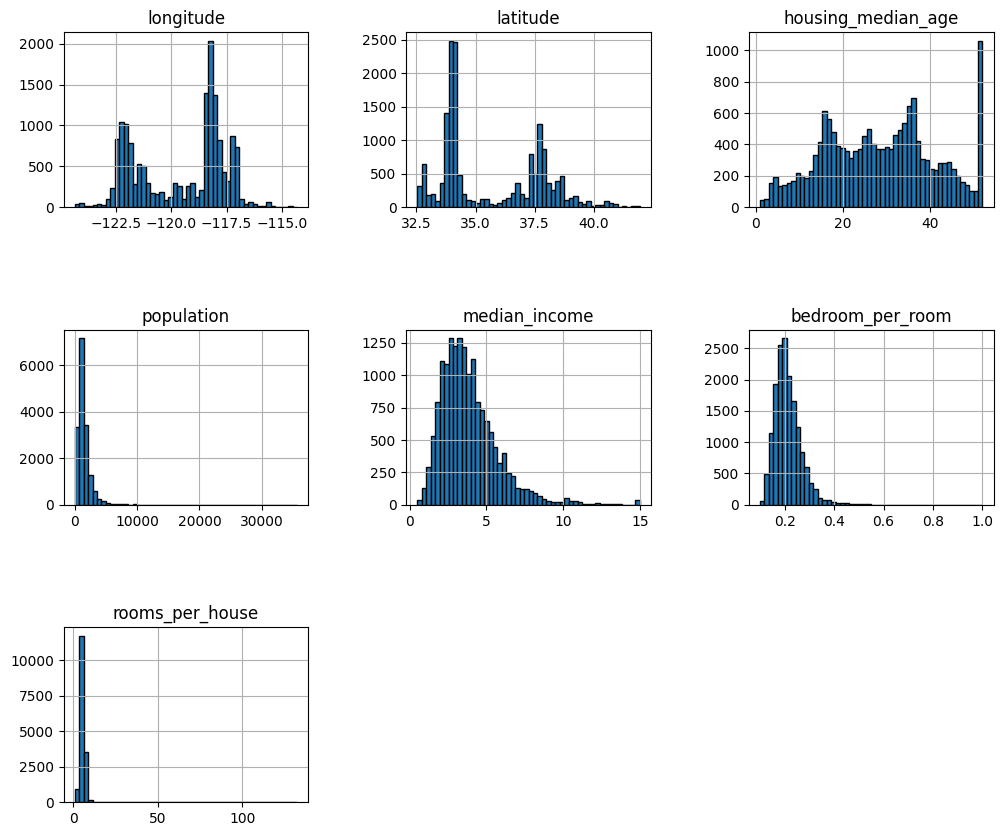

In [254]:
X_train.hist(figsize = (12, 10), bins = 50, edgecolor = 'black')
plt.subplots_adjust(hspace = 0.7, wspace = 0.4)

In [255]:
X_train.corr(numeric_only = True)

,longitude,latitude,housing_median_age,population,median_income,bedroom_per_room,rooms_per_house
longitude,1.000000,-0.924753,-0.109873,0.099824,-0.019501,0.095569,-0.033410
latitude,-0.924753,1.000000,0.010653,-0.106416,-0.076643,-0.115601,0.111456
housing_median_age,-0.109873,0.010653,1.000000,-0.295541,-0.113804,0.131608,-0.161266
population,0.099824,-0.106416,-0.295541,1.000000,0.004353,0.035173,-0.071238
median_income,-0.019501,-0.076643,-0.113804,0.004353,1.000000,-0.616968,0.358173
bedroom_per_room,0.095569,-0.115601,0.131608,0.035173,-0.616968,1.000000,-0.449190
rooms_per_house,-0.033410,0.111456,-0.161266,-0.071238,0.358173,-0.449190,1.000000


<Axes: >

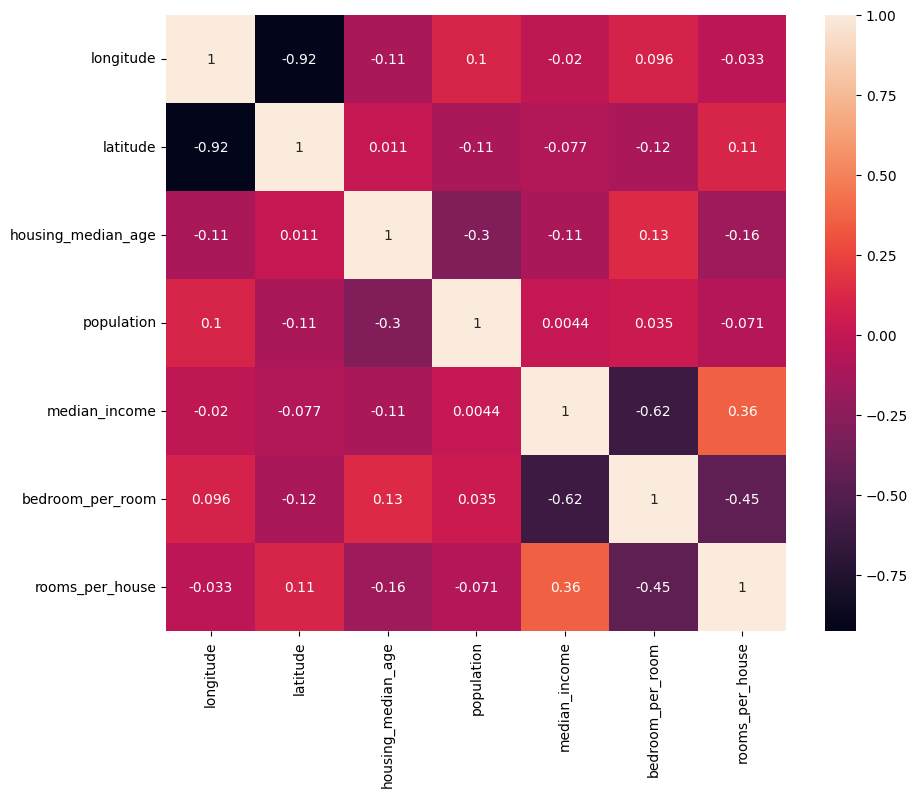

In [256]:
corr_matrix = X_train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)


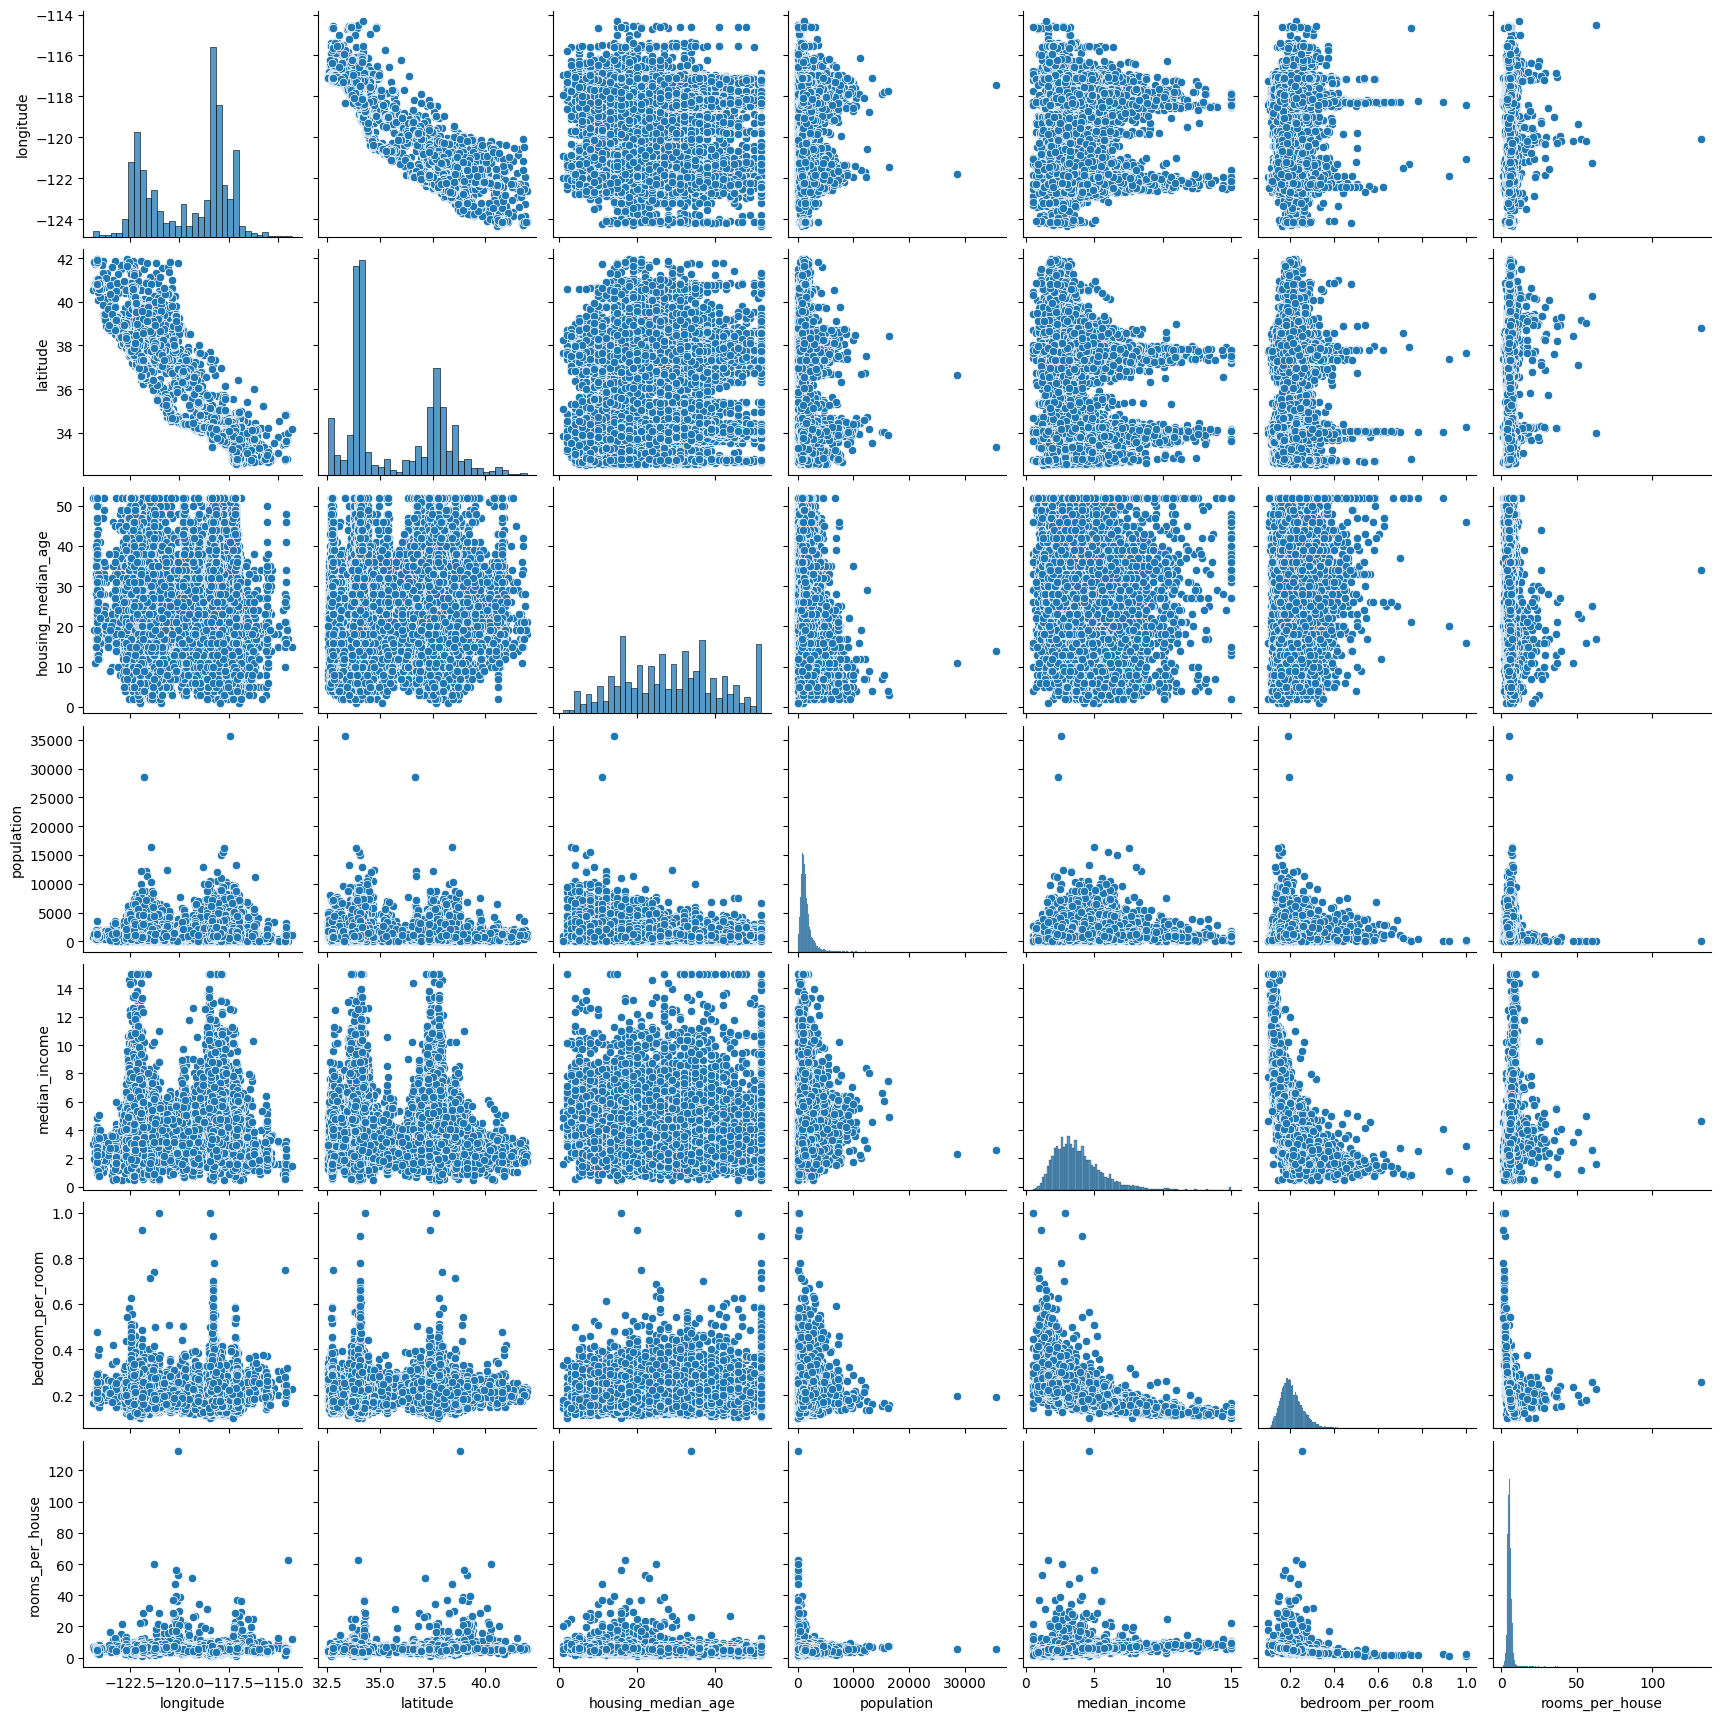

In [257]:
sns.pairplot(data = X_train)

In [258]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'population',
       'median_income', 'ocean_proximity', 'bedroom_per_room',
       'rooms_per_house'],
      dtype='str')

In [259]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 2072 to 2575
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   population          16512 non-null  float64
 4   median_income       16512 non-null  float64
 5   ocean_proximity     16512 non-null  str    
 6   bedroom_per_room    16336 non-null  float64
 7   rooms_per_house     16512 non-null  float64
dtypes: float64(7), str(1)
memory usage: 1.1 MB


In [260]:
numerical_features = ['longitude', 'latitude', 'housing_median_age', 'population',
       'median_income', 'bedroom_per_room',
       'rooms_per_house']

categorical_features=['ocean_proximity',]

numerical_pipeline=Pipeline(
    [
        ('impute', SimpleImputer(strategy='median')),
        #('log', FunctionTransformer(func = np.log1p)),
        ('std', StandardScaler())
    ]
)

categorical_pipeline=Pipeline(
    [
        ('impute', SimpleImputer(strategy = 'most_frequent')),
        ('ohe', OneHotEncoder(drop = 'first', handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    [
        ('numerical_pipeline', numerical_pipeline, numerical_features),
        ('categorical_pipeline', categorical_pipeline, categorical_features)
    ]
)

pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

Training:

In [261]:
pipe.fit(X = X_train, y = y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('categorical_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

Testing and Cross Validation:

In [262]:
print("RMSE Score: ", root_mean_squared_error(y_true = y_test, y_pred = pipe.predict(X_test)))

RMSE Score:  71483.56019105416


In [263]:
print("R2 Score: ", r2_score(y_true = y_test, y_pred = pipe.predict(X_test)))

R2 Score:  0.6206527949856133


In [264]:
print("Cross validation R2 Score:", np.mean(cross_val_score(estimator = pipe, X = X_train, y = y_train, scoring = 'r2', cv = 10)))

Cross validation R2 Score: 0.6203491321157967
